<a href="https://colab.research.google.com/github/SergeiVKalinin/spm-reconstruction/blob/main/02_reconstruction_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Reconstruction and Evaluation

Run a reconstruction model on a synthetic image and evaluate the result.

This notebook shows the complete single-model workflow.


In [1]:
!git clone https://github.com/SergeiVKalinin/spm-reconstruction.git 2>/dev/null ||  (cd /content/spm-reconstruction && git pull)
import sys
sys.path.insert(0, '/content/spm-reconstruction')
import importlib, spm_reconstruct
importlib.reload(spm_reconstruct)
print("Ready")

Ready


## 1. Generate a test image

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from spm_data import make_scan

data = make_scan(seed=42, Ny=128, Nx=128,
                 artifacts=['crash', 'oscillation', 'drift'])
print(data)

ScanData(Ny=128, Nx=128, labelled, seed=42)


## 2. Run a reconstruction model

`get_model()` returns a model by its (S, C, G, P) identifier.
`model.reconstruct(data)` returns a `ReconstructionResult`.


In [3]:
from spm_reconstruct import get_model, MODEL_REGISTRY

# M27 is the most complete single-pass model
model  = get_model("(S6, CT, GC, P1)")
result = model.reconstruct(data)

print(result)
print(f"\nKeys in result:")
print(f"  reconstructed : {result.reconstructed.shape}")
print(f"  uncertainty   : {result.uncertainty.shape}")
print(f"  quality       : {result.quality.shape}")
print(f"  runtime       : {result.runtime_s:.2f}s")
print(f"  diagnostics   : {list(result.diagnostics.keys())}")

ReconstructionResult(model='(S6, CT, GC, P1)', shape=(128,128), runtime=6.15s)

Keys in result:
  reconstructed : (128, 128)
  uncertainty   : (128, 128)
  quality       : (128, 128)
  runtime       : 6.15s
  diagnostics   : ['ell', 'L', 'gp_mask']


## 3. Look at the three universal outputs

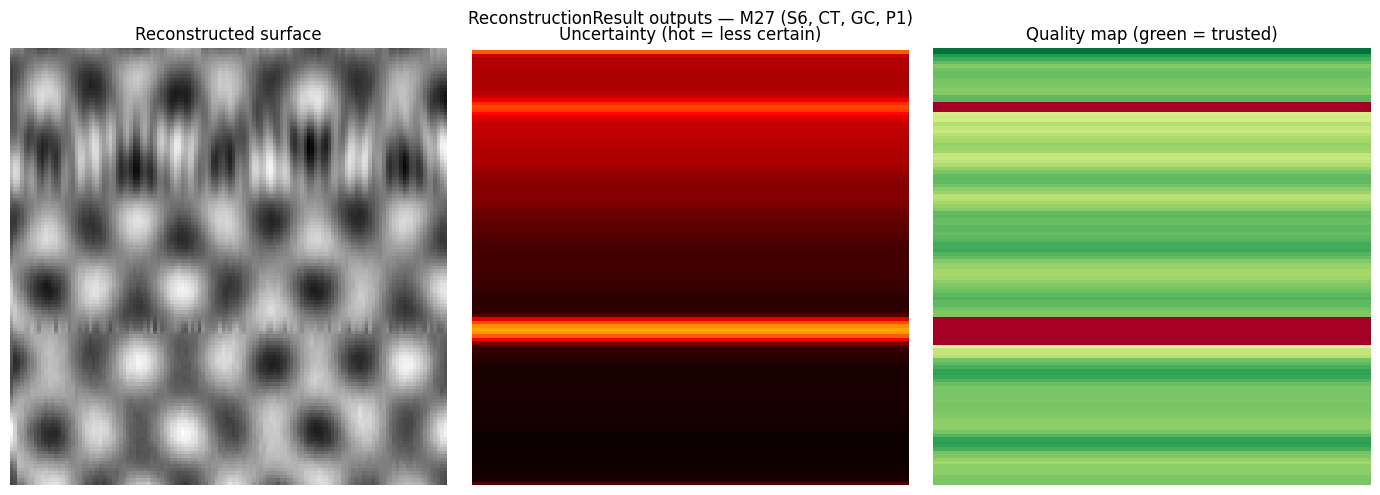

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(result.reconstructed, cmap='gray', origin='upper')
axes[0].set_title('Reconstructed surface')
axes[0].axis('off')

axes[1].imshow(result.uncertainty, cmap='hot', origin='upper')
axes[1].set_title('Uncertainty (hot = less certain)')
axes[1].axis('off')

axes[2].imshow(result.quality, cmap='RdYlGn',
               origin='upper', vmin=0, vmax=1)
axes[2].set_title('Quality map (green = trusted)')
axes[2].axis('off')

plt.suptitle('ReconstructionResult outputs — M27 (S6, CT, GC, P1)')
plt.tight_layout()
plt.show()

## 4. Compare with ground truth

RMSE corrupted  : 0.1311
RMSE reconstructed: 0.0775
Improvement     : 40.9%


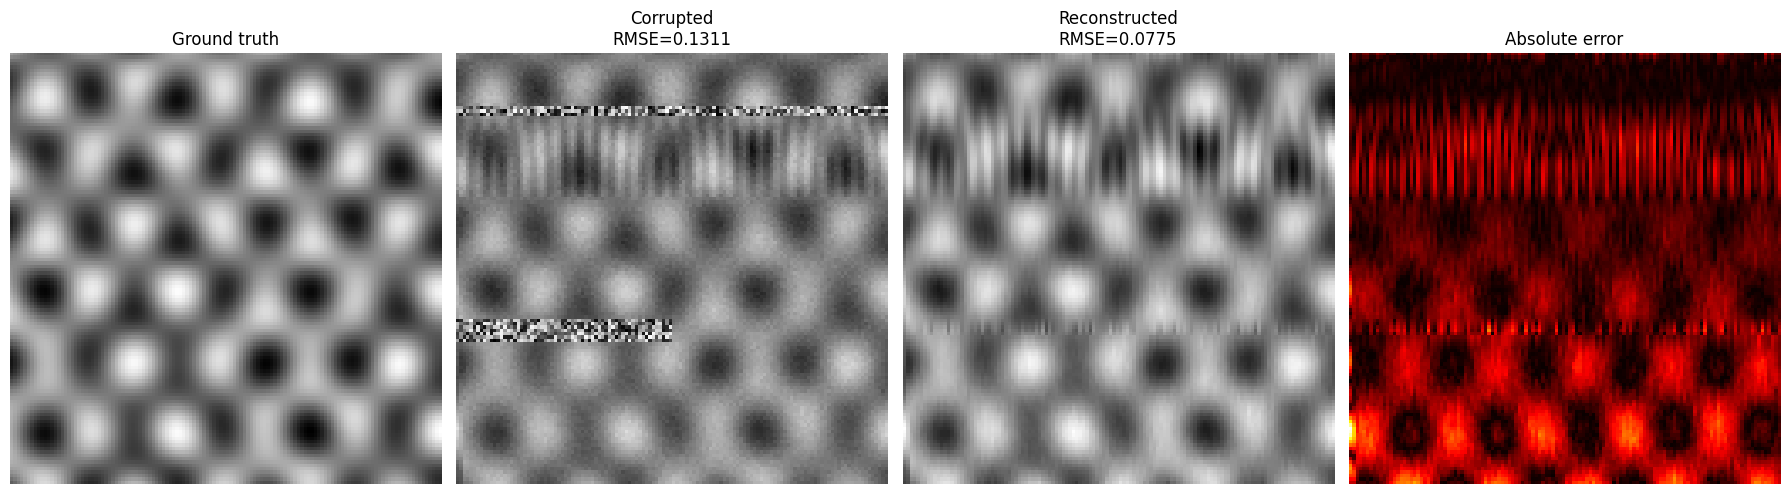

In [5]:
from spm_eval.metrics import rmse

rmse_corrupt = rmse(data.forward, data.true_surface)
rmse_recon   = rmse(result.reconstructed, data.true_surface)
improvement  = 100 * (rmse_corrupt - rmse_recon) / rmse_corrupt

print(f"RMSE corrupted  : {rmse_corrupt:.4f}")
print(f"RMSE reconstructed: {rmse_recon:.4f}")
print(f"Improvement     : {improvement:.1f}%")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, img, title in [
    (axes[0], data.true_surface,    'Ground truth'),
    (axes[1], data.forward,         f'Corrupted\nRMSE={rmse_corrupt:.4f}'),
    (axes[2], result.reconstructed, f'Reconstructed\nRMSE={rmse_recon:.4f}'),
    (axes[3], np.abs(result.reconstructed - data.true_surface), 'Absolute error'),
]:
    cmap = 'hot' if title == 'Absolute error' else 'gray'
    ax.imshow(img, cmap=cmap, origin='upper')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Run the evaluator

`Evaluator.evaluate()` computes all metrics automatically.
When `data.true_surface` is available, ground-truth metrics are included.
When it is not (real data), they are set to `None`.


In [6]:
from spm_reconstruct import Evaluator

ev     = Evaluator()
record = ev.evaluate(result, data)

print("Evaluation record:")
for key, val in record.items():
    if val is None:
        print(f"  {key:<25}: None")
    elif isinstance(val, np.ndarray):
        print(f"  {key:<25}: array {val.shape}")
    elif isinstance(val, float):
        print(f"  {key:<25}: {val:.5f}")
    else:
        print(f"  {key:<25}: {val}")

Evaluation record:
  model_id                 : (S6, CT, GC, P1)
  runtime_s                : 6.14742
  rmse                     : 0.07751
  mae                      : 0.06102
  ssim                     : 0.95009
  psd_rmse                 : 18.96362
  rmse_line                : array (128,)
  rmse_corrupt             : 0.07187
  rmse_clean               : 0.07785
  coverage95               : 0.44543
  coverage68               : 0.25403
  mean_uncertainty         : 0.02280
  nll                      : 6.88444
  classifier_auc           : 0.96245
  classifier_fpr           : 0.03734
  classifier_fnr           : 0.13333
  innov_rms_mean           : 0.08405
  innov_rms_max            : 0.59773
  r_final                  : 0.00043


## 6. Per-line RMSE

`rmse_line` shows where the reconstruction improves most —
typically at crash lines and other artifact locations.


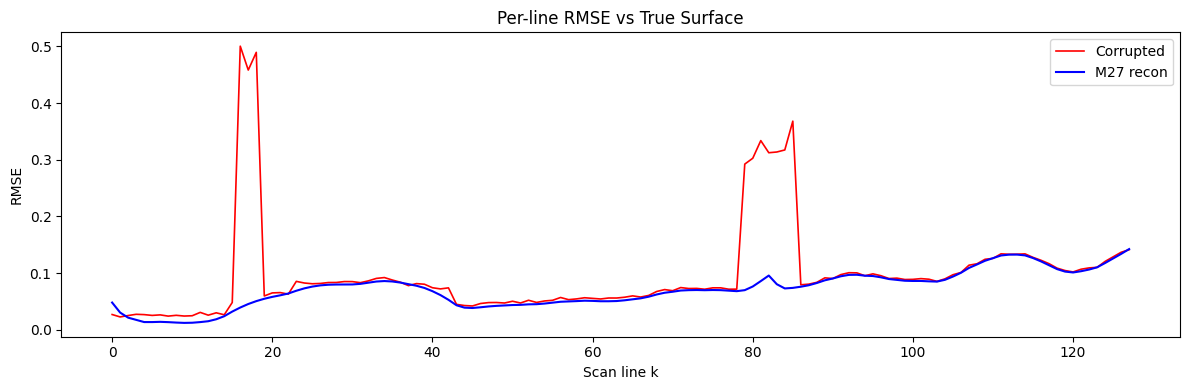

In [7]:
import numpy as np

rmse_line_corrupt = np.sqrt(
    np.mean((data.forward - data.true_surface)**2, axis=1))

plt.figure(figsize=(12, 4))
plt.plot(rmse_line_corrupt, label='Corrupted',  color='red',  lw=1.2)
plt.plot(record['rmse_line'], label='M27 recon', color='blue', lw=1.5)
plt.xlabel('Scan line k')
plt.ylabel('RMSE')
plt.title('Per-line RMSE vs True Surface')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Kalman monitoring signals

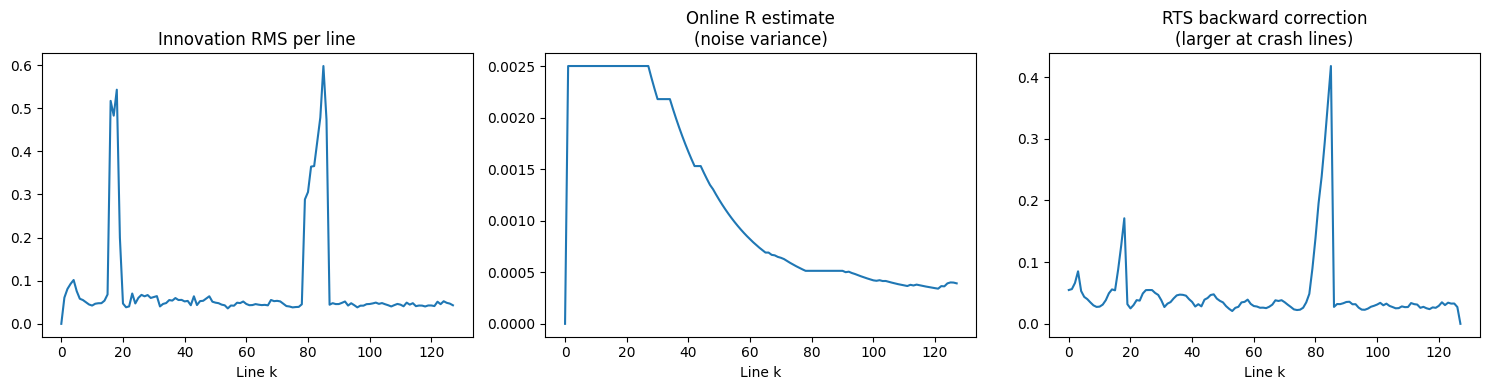

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(result.innovation_rms)
axes[0].set_title('Innovation RMS per line')
axes[0].set_xlabel('Line k')

axes[1].plot(result.r_estimate)
axes[1].set_title('Online R estimate\n(noise variance)')
axes[1].set_xlabel('Line k')

axes[2].plot(result.rts_correction)
axes[2].set_title('RTS backward correction\n(larger at crash lines)')
axes[2].set_xlabel('Line k')

plt.tight_layout()
plt.show()